In [2]:
import numpy as np
import matplotlib.pyplot as plt
import finufft
from scipy.fft import fft
from matplotlib.colors import LogNorm
from matplotlib import colors
import cmasher as cmr

In [3]:
def structure_3points_1D(sample, L, n_modes):

    sample = sample - L/2
    sample = (sample / L) * 2 * np.pi
    c = np.ones_like(sample, dtype = np.complex128)
    rho_k = finufft.nufft1d1(sample, c, 2*n_modes + 1)
    rho_k_1 = rho_k.copy()
    rho_k_1[n_modes] = 0

    # grid (k+k'), rho(k+k')*
    
    k_kp_ind = np.arange(- n_modes, n_modes + 1)
    k_kp_ind = k_kp_ind[:, None] + k_kp_ind[None, :]

    msk_k_kp_ind = np.where((k_kp_ind >= - n_modes) & (k_kp_ind <= n_modes), k_kp_ind, 0)
    msk_k_kp_ind = msk_k_kp_ind + n_modes
    msk_k_kp_ind = msk_k_kp_ind.astype(int)
    rho_kkp = np.conj(rho_k_1[msk_k_kp_ind])

    rho_k_rev = rho_k_1[:, None]
    rhok_rhokp = rho_k_rev * rho_k_1[None, :]

    S3 = rhok_rhokp * rho_kkp/len(sample)

    return S3

Quasicrystal

In [4]:
N = 10000;
tau = (1 + np.sqrt(5))/2;
beta = 0.1;

x_N = np.arange(1, N+1) + (1/tau) * np.floor(np.arange(1, N+1)/tau + beta);

In [5]:
n_modes_5 = 2000;
L5 = max(x_N) - min(x_N);
S3 = structure_3points_1D(x_N, L5, n_modes_5);

In [6]:
grid_5 = np.arange(- n_modes_5, n_modes_5 + 1)
S3_real = np.real(S3)

In [7]:
# S3 in 4 quadrants

S3_1st = S3_real[n_modes_5:, n_modes_5:]
S3_2nd = S3_real[:n_modes_5, n_modes_5:]
S3_3rd = S3_real[:n_modes_5, :n_modes_5]
S3_4th = S3_real[n_modes_5:, :n_modes_5]

In [9]:
vmin, vmax = np.nanpercentile(S3_real, [0.5, 99.5])

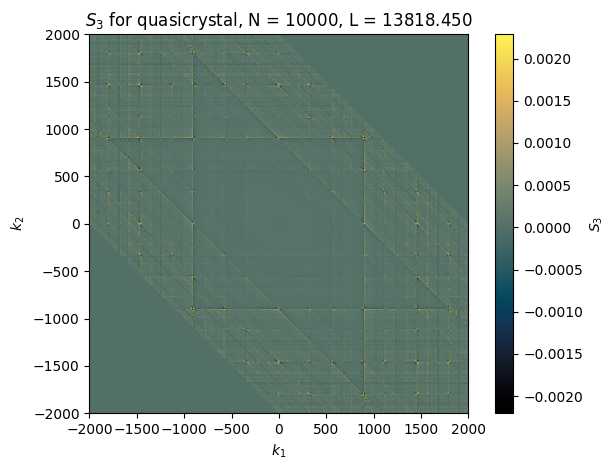

In [10]:
# S3
plt.figure()

plt.imshow(S3_real, origin = 'lower', cmap = cmr.eclipse, extent=[grid_5[0], grid_5[-1], grid_5[0], grid_5[-1]], 
           vmin = vmin, vmax=vmax)
plt.xlabel("$k_1$");
plt.ylabel("$k_2$");
plt.title(rf"$S_3$ for quasicrystal, N = {N}, L = {L5:.3f}")
plt.colorbar(label = "$S_3$")
plt.tight_layout();

1st quadrant

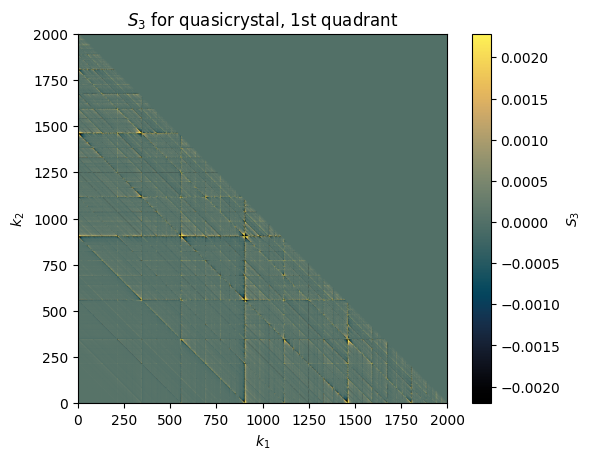

In [11]:
plt.figure()
plt.imshow(S3_1st, origin = 'lower', 
           extent=[grid_5[n_modes_5], grid_5[-1], grid_5[n_modes_5], grid_5[-1]], cmap = cmr.eclipse, 
           vmin = vmin, vmax=vmax)
plt.xlabel("$k_1$");
plt.ylabel("$k_2$");
plt.title(rf"$S_3$ for quasicrystal, 1st quadrant")
plt.colorbar(label = "$S_3$")

Map into other quadrants:

In [12]:
S3_2nd_up = np.zeros_like(S3_1st)
S3_2nd_down = np.zeros_like(S3_1st)

Upper second quadrant $k_1 \rightarrow -k_1, \, k_2 \rightarrow k_1 + k_2$

In [13]:
for i in range(n_modes_5):
    for j in range(n_modes_5 - i):      
        ip = n_modes_5 - 1 - i          
        jp = i + j                      
        S3_2nd_up[ip, jp] = S3_1st[i, j]

Lower second quadrant $k_1 \rightarrow-(k_1 + k_2),  \, k_2 \rightarrow k_1$

In [14]:
for i in range(n_modes_5):
    for j in range(n_modes_5 - i):
        ip = n_modes_5 - 1 - (i + j)
        jp = i
        S3_2nd_down[ip, jp] = S3_1st[i, j]

Text(0.5, 1.0, 'Upper second quadrant')

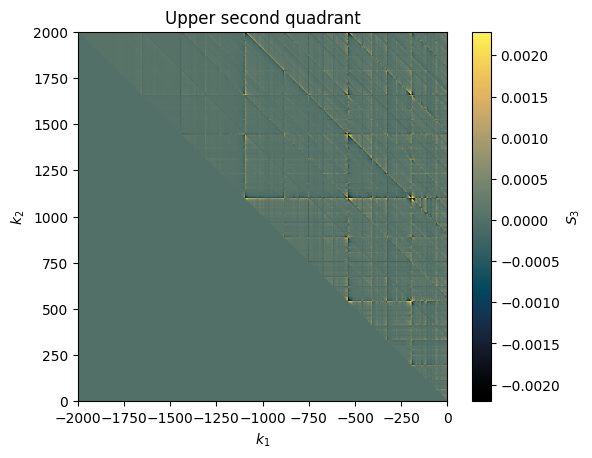

In [15]:
plt.figure()
plt.imshow(S3_2nd_up, origin = 'lower', extent=[-n_modes_5, 0, 0, n_modes_5], cmap = cmr.eclipse, 
           vmin = vmin, vmax=vmax)
plt.xlabel("$k_1$");
plt.ylabel("$k_2$");
plt.colorbar(label = "$S_3$")
plt.title("Upper second quadrant")

Text(0.5, 1.0, 'Lower second quadrant')

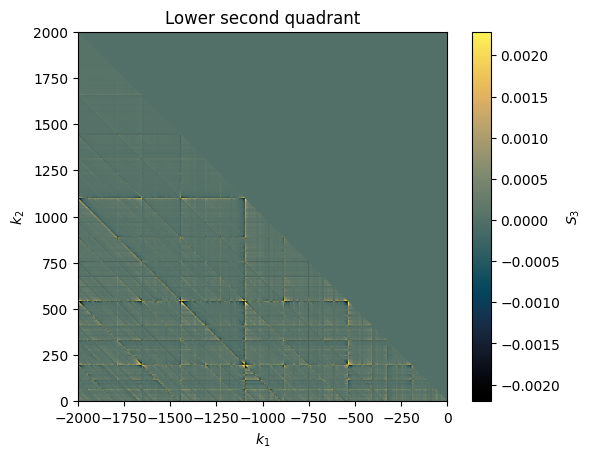

In [16]:
plt.figure()
plt.imshow(S3_2nd_down, origin = 'lower', extent=[-n_modes_5, 0, 0, n_modes_5], cmap = cmr.eclipse, 
           vmin = vmin, vmax=vmax)
plt.xlabel("$k_1$");
plt.ylabel("$k_2$");
plt.colorbar(label = "$S_3$")
plt.title("Lower second quadrant")

In [17]:
S3_2nd_new = S3_2nd_up + S3_2nd_down

Text(0.5, 1.0, 'Actual quadrant 2')

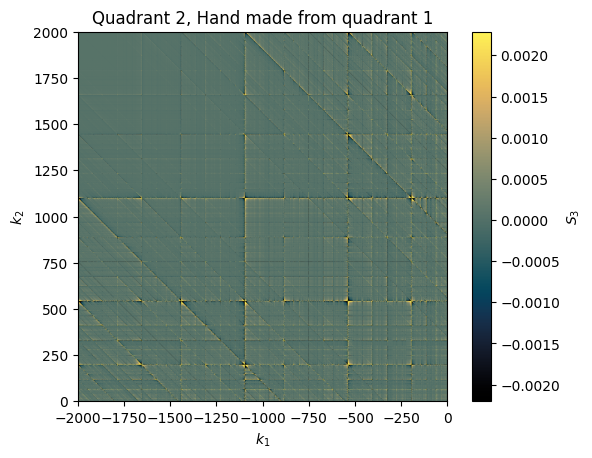

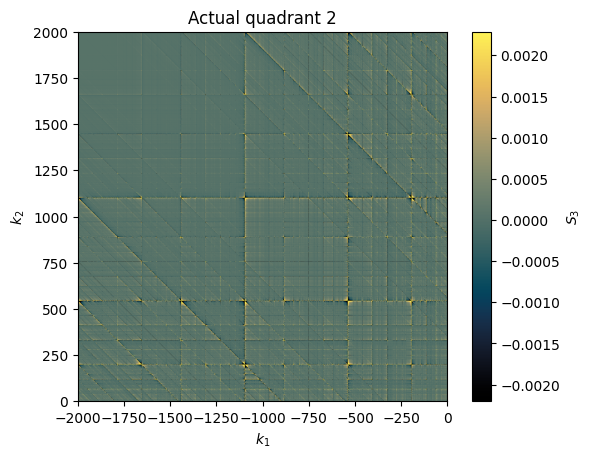

In [18]:
plt.figure()
plt.imshow(S3_2nd_new, origin = 'lower', extent=[-n_modes_5, 0, 0, n_modes_5], cmap = cmr.eclipse, 
           vmin = vmin, vmax=vmax)
plt.xlabel("$k_1$");
plt.ylabel("$k_2$");
plt.colorbar(label = "$S_3$")
plt.title(rf"Quadrant 2, Hand made from quadrant 1")


plt.figure()
plt.imshow(S3_2nd, origin = 'lower', extent=[-n_modes_5, 0, 0, n_modes_5], cmap = cmr.eclipse, 
           vmin = vmin, vmax=vmax)
plt.xlabel("$k_1$");
plt.ylabel("$k_2$");
plt.colorbar(label = "$S_3$")
plt.title(rf"Actual quadrant 2")

3rd quadrant $k_1 \rightarrow -k_1, \, k_2 \rightarrow -k_2$

In [19]:
S3_3rd_new = np.zeros_like(S3_1st)

In [20]:
for i in range(n_modes_5):
    for j in range(n_modes_5 - i):
        ip = n_modes_5 - 1 - i
        jp = n_modes_5 - 1 - j
        S3_3rd_new[ip, jp] = S3_1st[i, j]

Text(0.5, 1.0, 'Actual quadrant 3')

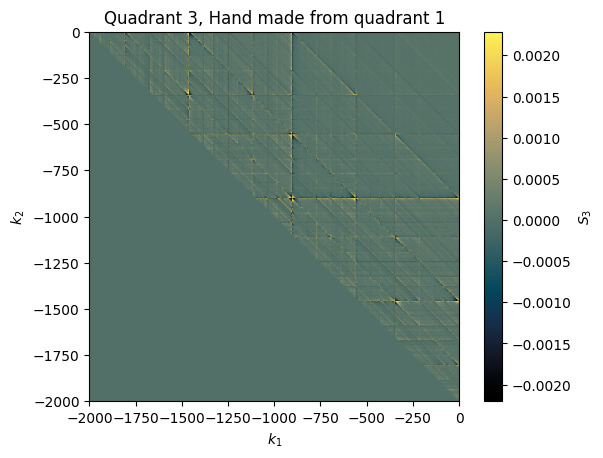

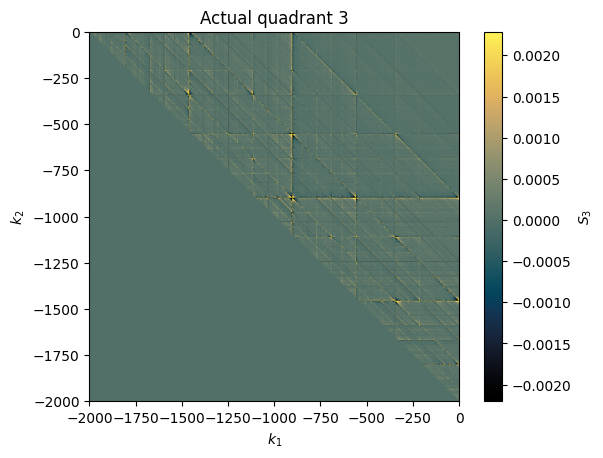

In [21]:
plt.figure()
plt.imshow(S3_3rd_new, origin = 'lower', extent=[-n_modes_5, 0, -n_modes_5, 0], cmap = cmr.eclipse, 
           vmin = vmin, vmax=vmax)
plt.xlabel("$k_1$");
plt.ylabel("$k_2$");
plt.colorbar(label = "$S_3$")
plt.title(rf"Quadrant 3, Hand made from quadrant 1")


plt.figure()
plt.imshow(S3_3rd, origin = 'lower', extent=[-n_modes_5, 0, -n_modes_5, 0], cmap = cmr.eclipse, 
           vmin = vmin, vmax=vmax)
plt.xlabel("$k_1$");
plt.ylabel("$k_2$");
plt.colorbar(label = "$S_3$")
plt.title(rf"Actual quadrant 3")

4th quadrant: 

Upper: $k_1 \rightarrow k_1 + k _2, \, k_2 \rightarrow -k1$

Lower: $k_1 \rightarrow k_1, \, k_2 \rightarrow -(k_1 + k_2)$

In [22]:
S3_4th_up = np.zeros_like(S3_1st)
S3_4th_down = np.zeros_like(S3_1st)

In [23]:
for i in range(n_modes_5):
    for j in range(n_modes_5 - i):
        ip = i + j
        jp = n_modes_5 - 1 - i
        S3_4th_up[ip, jp] = S3_1st[i, j]

In [24]:
for i in range(n_modes_5):
    for j in range(n_modes_5 - i):
        ip = i
        jp = n_modes_5 - 1 - (i + j)
        S3_4th_down[ip, jp] = S3_1st[i, j]

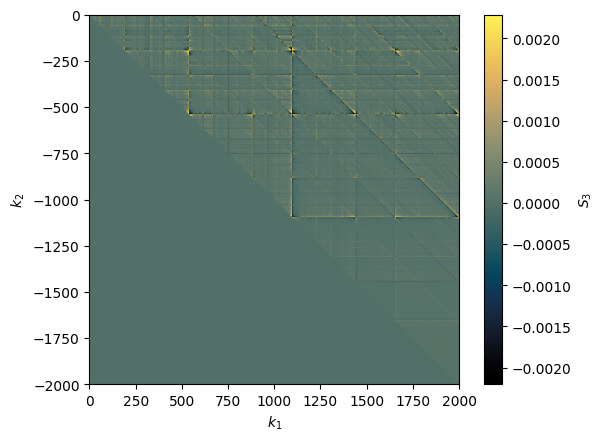

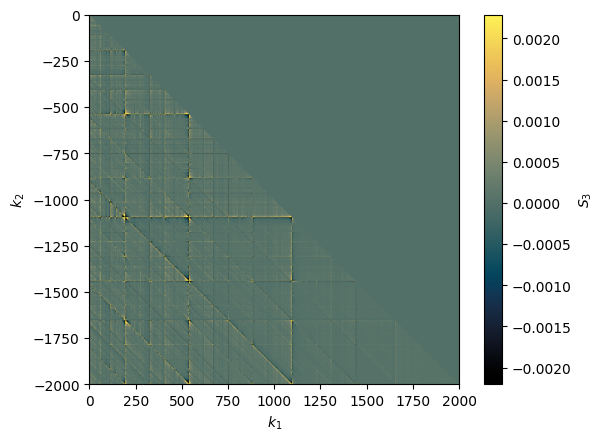

In [25]:
plt.figure()
plt.imshow(S3_4th_up, origin = 'lower', extent=[0, n_modes_5, -n_modes_5, 0], cmap = cmr.eclipse, 
           vmin = vmin, vmax=vmax)
plt.xlabel("$k_1$");
plt.ylabel("$k_2$");
plt.colorbar(label = "$S_3$")


plt.figure()
plt.imshow(S3_4th_down, origin = 'lower', extent=[0, n_modes_5, -n_modes_5, 0], cmap = cmr.eclipse, 
           vmin = vmin, vmax=vmax)
plt.xlabel("$k_1$");
plt.ylabel("$k_2$");
plt.colorbar(label = "$S_3$")

In [26]:
S3_4th_new = S3_4th_up + S3_4th_down

Text(0.5, 1.0, 'Actual quadrant 4')

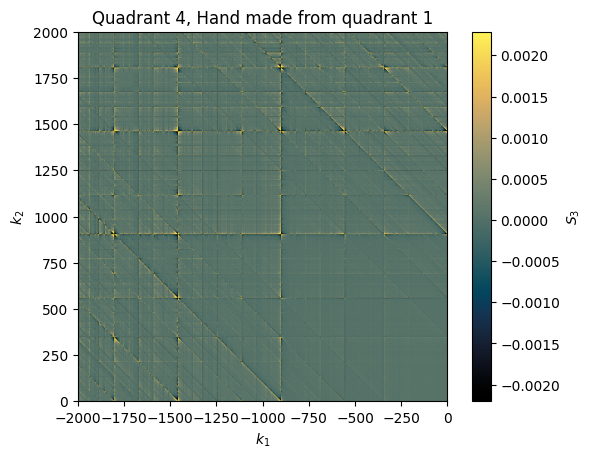

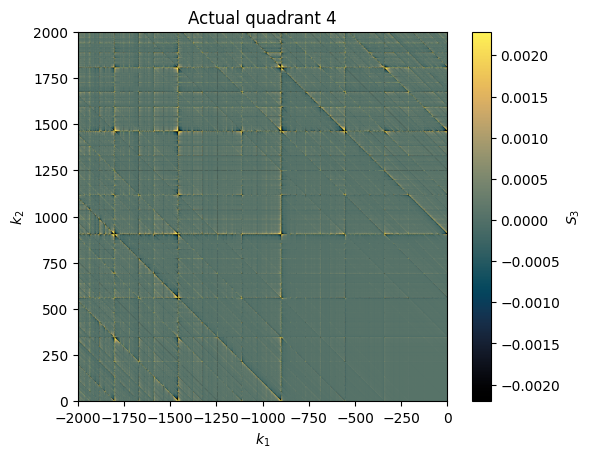

In [27]:
plt.figure()
plt.imshow(S3_4th_new, origin = 'lower', extent=[-n_modes_5, 0, 0, n_modes_5], cmap = cmr.eclipse, 
           vmin = vmin, vmax=vmax)
plt.xlabel("$k_1$");
plt.ylabel("$k_2$");
plt.colorbar(label = "$S_3$")
plt.title(rf"Quadrant 4, Hand made from quadrant 1")


plt.figure()
plt.imshow(S3_4th, origin = 'lower', extent=[-n_modes_5, 0, 0, n_modes_5], cmap = cmr.eclipse, 
           vmin = vmin, vmax=vmax)
plt.xlabel("$k_1$");
plt.ylabel("$k_2$");
plt.colorbar(label = "$S_3$")
plt.title(rf"Actual quadrant 4")